In [2]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import os

# Download
path = kagglehub.dataset_download("olcaybolat1/dermatology-dataset-classification")

# Load
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"✅ Loaded {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Loaded 366 rows, 35 columns


,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,age,class
0,2,2,0,3,0,0,0,0,1,0,...,0,0,3,0,0,0,1,0,55,2
1,3,3,3,2,1,0,0,0,1,1,...,0,0,0,0,0,0,1,0,8,1
2,2,1,2,3,1,3,0,3,0,0,...,0,2,3,2,0,0,2,3,26,3
3,2,2,2,0,0,0,0,0,3,2,...,3,0,0,0,0,0,3,0,40,1
4,2,3,2,2,2,2,0,2,0,0,...,2,3,2,3,0,0,2,3,45,3


In [3]:
# See what you have
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nTarget classes: {sorted(df['class'].unique())}")

Dataset: 366 rows, 35 columns

Column names:
['erythema', 'scaling', 'definite_borders', 'itching', 'koebner_phenomenon', 'polygonal_papules', 'follicular_papules', 'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement', 'family_history', 'melanin_incontinence', 'eosinophils_infiltrate', 'PNL_infiltrate', 'fibrosis_papillary_dermis', 'exocytosis', 'acanthosis', 'hyperkeratosis', 'parakeratosis', 'clubbing_rete_ridges', 'elongation_rete_ridges', 'thinning_suprapapillary_epidermis', 'spongiform_pustule', 'munro_microabcess', 'focal_hypergranulosis', 'disappearance_granular_layer', 'vacuolisation_damage_basal_layer', 'spongiosis', 'saw_tooth_appearance_retes', 'follicular_horn_plug', 'perifollicular_parakeratosis', 'inflammatory_mononuclear_infiltrate', 'band_like_infiltrate', 'age', 'class']

Target classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


In [4]:
# Find missing values (represented as ? in original)
print("Missing values per column:")
print(df.isin(['?']).sum())

Missing values per column:
erythema                               0
scaling                                0
definite_borders                       0
itching                                0
koebner_phenomenon                     0
polygonal_papules                      0
follicular_papules                     0
oral_mucosal_involvement               0
knee_and_elbow_involvement             0
scalp_involvement                      0
family_history                         0
melanin_incontinence                   0
eosinophils_infiltrate                 0
PNL_infiltrate                         0
fibrosis_papillary_dermis              0
exocytosis                             0
acanthosis                             0
hyperkeratosis                         0
parakeratosis                          0
clubbing_rete_ridges                   0
elongation_rete_ridges                 0
thinning_suprapapillary_epidermis      0
spongiform_pustule                     0
munro_microabcess             

In [5]:
# See how many samples per disease type
print("Disease class distribution:")
print(df['class'].value_counts().sort_index())
print("\nClass names:")
print("1 = psoriasis")
print("2 = seborrheic dermatitis") 
print("3 = lichen planus")
print("4 = pityriasis rosea")
print("5 = chronic dermatitis")
print("6 = pityriasis rubra pilaris")

Disease class distribution:
class
1    112
2     61
3     72
4     49
5     52
6     20
Name: count, dtype: int64

Class names:
1 = psoriasis
2 = seborrheic dermatitis
3 = lichen planus
4 = pityriasis rosea
5 = chronic dermatitis
6 = pityriasis rubra pilaris


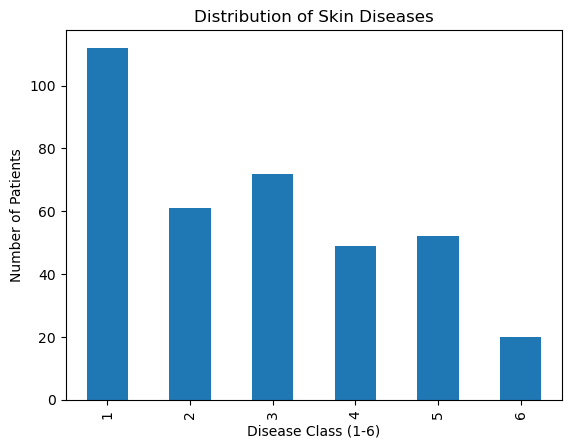

In [6]:
import matplotlib.pyplot as plt

# Plot class distribution
df['class'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Skin Diseases')
plt.xlabel('Disease Class (1-6)')
plt.ylabel('Number of Patients')
plt.show()

In [7]:
# Features are 0-3 scale, age is numeric
print(df.dtypes)
print("\nFirst 5 rows of first 10 features:")
print(df.iloc[:5, :10])

erythema                                int64
scaling                                 int64
definite_borders                        int64
itching                                 int64
koebner_phenomenon                      int64
polygonal_papules                       int64
follicular_papules                      int64
oral_mucosal_involvement                int64
knee_and_elbow_involvement              int64
scalp_involvement                       int64
family_history                          int64
melanin_incontinence                    int64
eosinophils_infiltrate                  int64
PNL_infiltrate                          int64
fibrosis_papillary_dermis               int64
exocytosis                              int64
acanthosis                              int64
hyperkeratosis                          int64
parakeratosis                           int64
clubbing_rete_ridges                    int64
elongation_rete_ridges                  int64
thinning_suprapapillary_epidermis 

In [8]:
# Summary of all numeric features
df.describe()

,erythema,scaling,definite_borders,itching,koebner_phenomenon,polygonal_papules,follicular_papules,oral_mucosal_involvement,knee_and_elbow_involvement,scalp_involvement,...,focal_hypergranulosis,disappearance_granular_layer,vacuolisation_damage_basal_layer,spongiosis,saw_tooth_appearance_retes,follicular_horn_plug,perifollicular_parakeratosis,inflammatory_mononuclear_infiltrate,band_like_infiltrate,class
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,...,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,2.068306,1.795082,1.549180,1.366120,0.633880,0.448087,0.166667,0.377049,0.614754,0.519126,...,0.393443,0.464481,0.456284,0.953552,0.453552,0.103825,0.114754,1.866120,0.554645,2.803279
std,0.664753,0.701527,0.907525,1.138299,0.908016,0.957327,0.570588,0.834147,0.982979,0.905639,...,0.849406,0.864899,0.954873,1.130172,0.954744,0.450433,0.488723,0.726108,1.105908,1.597803
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,3.000000
75%,2.000000,2.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,2.000000,0.000000,4.000000
max,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,6.000000


In [9]:
# Replace '?' with NaN and convert to numbers
df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Check how many missing ages
print(f"Missing ages: {df['age'].isnull().sum()}")

# Fill missing ages with median
df['age'].fillna(df['age'].median(), inplace=True)

print("✅ Age column fixed!")

Missing ages: 8
✅ Age column fixed!


C:\Users\Technology\AppData\Local\Temp\ipykernel_11604\4113590488.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


In [10]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Check for duplicate patients based on all features except class
duplicate_patients = df.iloc[:, :-1].duplicated().sum()
print(f"Duplicate patient profiles (same features): {duplicate_patients}")

Number of duplicate rows: 0
Duplicate patient profiles (same features): 0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Basic info
print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Shape: {df.shape}")
print(f"Features: {df.shape[1]-1} predictors + 1 target")
print(f"Samples: {df.shape[0]} patients")
print(f"\nTarget column: 'class'")
print(f"Classes: {sorted(df['class'].unique())}")

DATASET OVERVIEW
Shape: (366, 35)
Features: 34 predictors + 1 target
Samples: 366 patients

Target column: 'class'
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


CLASS DISTRIBUTION
Class 1 (Psoriasis): 112 patients (30.6%)
Class 2 (Seborrheic Dermatitis): 61 patients (16.7%)
Class 3 (Lichen Planus): 72 patients (19.7%)
Class 4 (Pityriasis Rosea): 49 patients (13.4%)
Class 5 (Chronic Dermatitis): 52 patients (14.2%)
Class 6 (Pityriasis Rubra Pilaris): 20 patients (5.5%)


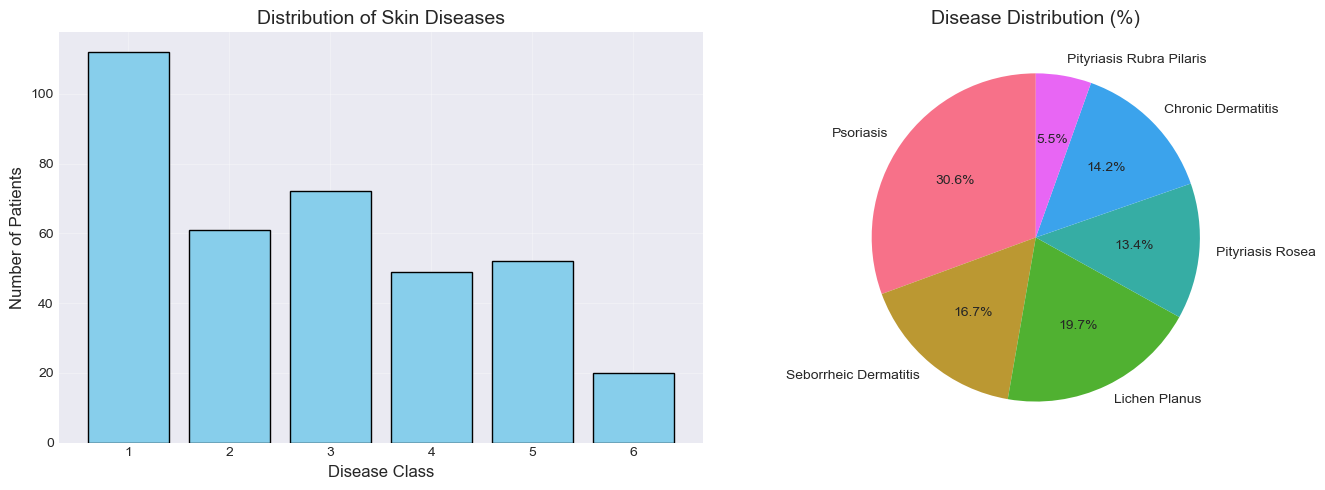


Imbalance ratio: 5.60:1
⚠️ Dataset is imbalanced - consider using stratified sampling


In [12]:
# Class distribution
print("="*50)
print("CLASS DISTRIBUTION")
print("="*50)

class_counts = df['class'].value_counts().sort_index()
class_percentages = (class_counts / len(df)) * 100

class_names = {
    1: "Psoriasis",
    2: "Seborrheic Dermatitis", 
    3: "Lichen Planus",
    4: "Pityriasis Rosea",
    5: "Chronic Dermatitis",
    6: "Pityriasis Rubra Pilaris"
}

for cls in class_counts.index:
    print(f"Class {cls} ({class_names[cls]}): {class_counts[cls]} patients ({class_percentages[cls]:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(class_counts.index, class_counts.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Disease Class', fontsize=12)
axes[0].set_ylabel('Number of Patients', fontsize=12)
axes[0].set_title('Distribution of Skin Diseases', fontsize=14)
axes[0].set_xticks(range(1, 7))
axes[0].grid(True, alpha=0.3)

# Pie chart
axes[1].pie(class_counts.values, labels=[class_names[c] for c in class_counts.index], 
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Disease Distribution (%)', fontsize=14)

plt.tight_layout()
plt.show()

# Check for imbalance
min_class = class_counts.min()
max_class = class_counts.max()
print(f"\nImbalance ratio: {max_class/min_class:.2f}:1")
if max_class/min_class > 2:
    print("⚠️ Dataset is imbalanced - consider using stratified sampling")

AGE ANALYSIS
Age statistics:
  Mean: 36.3 years
  Median: 35.0 years
  Std: 15.2 years
  Min: 0 years
  Max: 75 years


C:\Users\Technology\AppData\Local\Temp\ipykernel_11604\79242403.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(age_by_class, labels=[class_names[c] for c in sorted(df['class'].unique())],


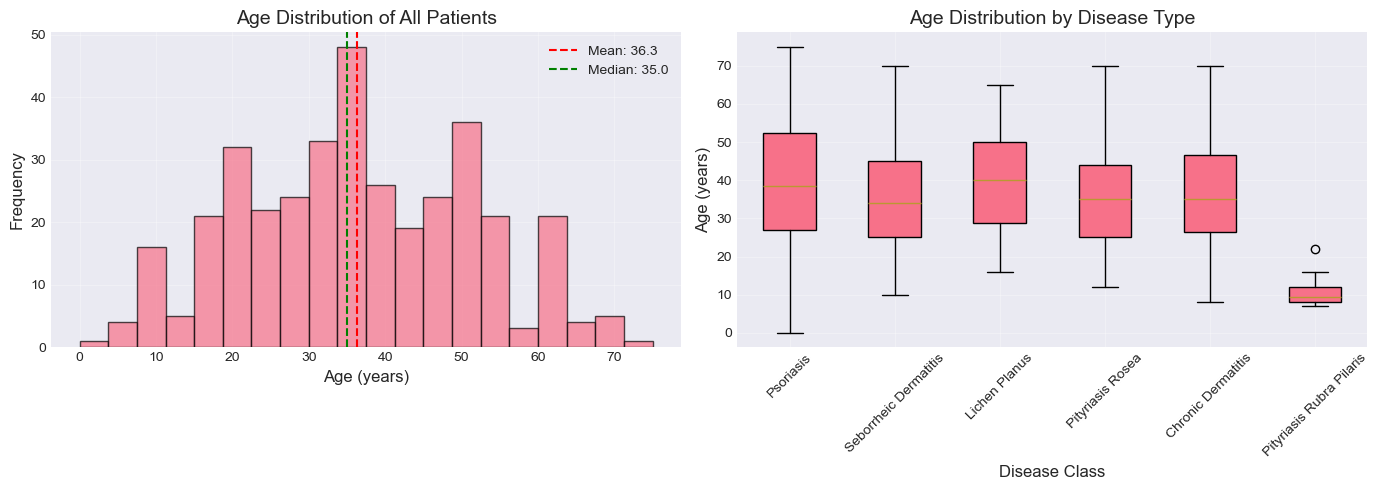

In [13]:
print("="*50)
print("AGE ANALYSIS")
print("="*50)

# Age statistics
print(f"Age statistics:")
print(f"  Mean: {df['age'].mean():.1f} years")
print(f"  Median: {df['age'].median():.1f} years")
print(f"  Std: {df['age'].std():.1f} years")
print(f"  Min: {df['age'].min():.0f} years")
print(f"  Max: {df['age'].max():.0f} years")

# Age by disease class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['age'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', label=f'Median: {df["age"].median():.1f}')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Age Distribution of All Patients', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by class
age_by_class = [df[df['class'] == cls]['age'] for cls in sorted(df['class'].unique())]
bp = axes[1].boxplot(age_by_class, labels=[class_names[c] for c in sorted(df['class'].unique())], 
                      patch_artist=True)
axes[1].set_xlabel('Disease Class', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution by Disease Type', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

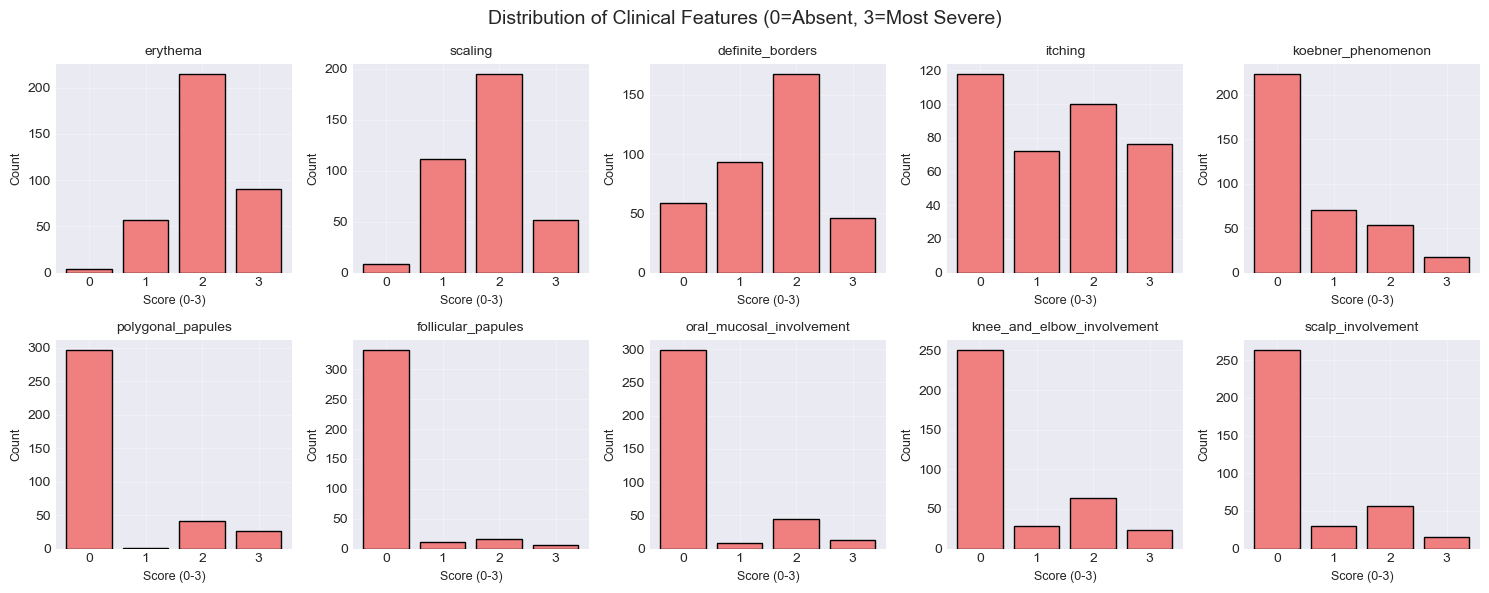


Clinical Features Summary (0-3 scale):
       erythema  scaling  definite_borders  itching  koebner_phenomenon  \
count    366.00    366.0            366.00   366.00              366.00   
mean       2.07      1.8              1.55     1.37                0.63   
std        0.66      0.7              0.91     1.14                0.91   
min        0.00      0.0              0.00     0.00                0.00   
25%        2.00      1.0              1.00     0.00                0.00   
50%        2.00      2.0              2.00     1.00                0.00   
75%        2.00      2.0              2.00     2.00                1.00   
max        3.00      3.0              3.00     3.00                3.00   

       polygonal_papules  follicular_papules  oral_mucosal_involvement  \
count             366.00              366.00                    366.00   
mean                0.45                0.17                      0.38   
std                 0.96                0.57                  

In [14]:
# Select clinical features (first 10) for visualization
clinical_features = ['erythema', 'scaling', 'definite_borders', 'itching', 
                     'koebner_phenomenon', 'polygonal_papules', 'follicular_papules',
                     'oral_mucosal_involvement', 'knee_and_elbow_involvement', 'scalp_involvement']

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx, feature in enumerate(clinical_features):
    # Count values 0-3
    value_counts = df[feature].value_counts().sort_index()
    axes[idx].bar(value_counts.index, value_counts.values, color='lightcoral', edgecolor='black')
    axes[idx].set_title(feature, fontsize=10)
    axes[idx].set_xlabel('Score (0-3)', fontsize=9)
    axes[idx].set_ylabel('Count', fontsize=9)
    axes[idx].set_xticks(range(4))
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribution of Clinical Features (0=Absent, 3=Most Severe)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nClinical Features Summary (0-3 scale):")
print(df[clinical_features].describe().round(2))

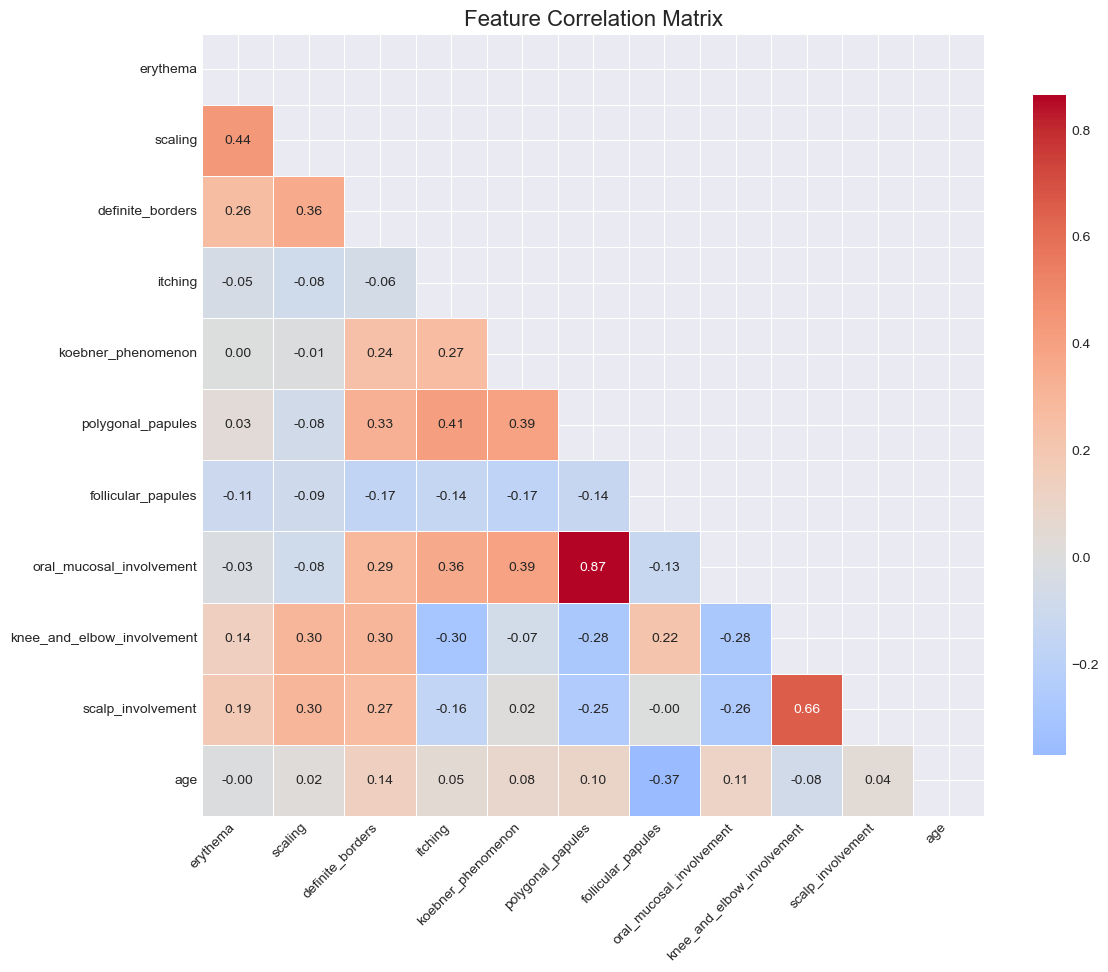


HIGHLY CORRELATED FEATURES (|r| > 0.5)
polygonal_papules ↔ oral_mucosal_involvement: 0.865
knee_and_elbow_involvement ↔ scalp_involvement: 0.659


In [15]:
# Correlation matrix (select subset for readability)
selected_features = clinical_features + ['age']
corr_matrix = df[selected_features].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find highly correlated features
print("\n" + "="*50)
print("HIGHLY CORRELATED FEATURES (|r| > 0.5)")
print("="*50)
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i,j]) > 0.5:
            print(f"{corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i,j]:.3f}")

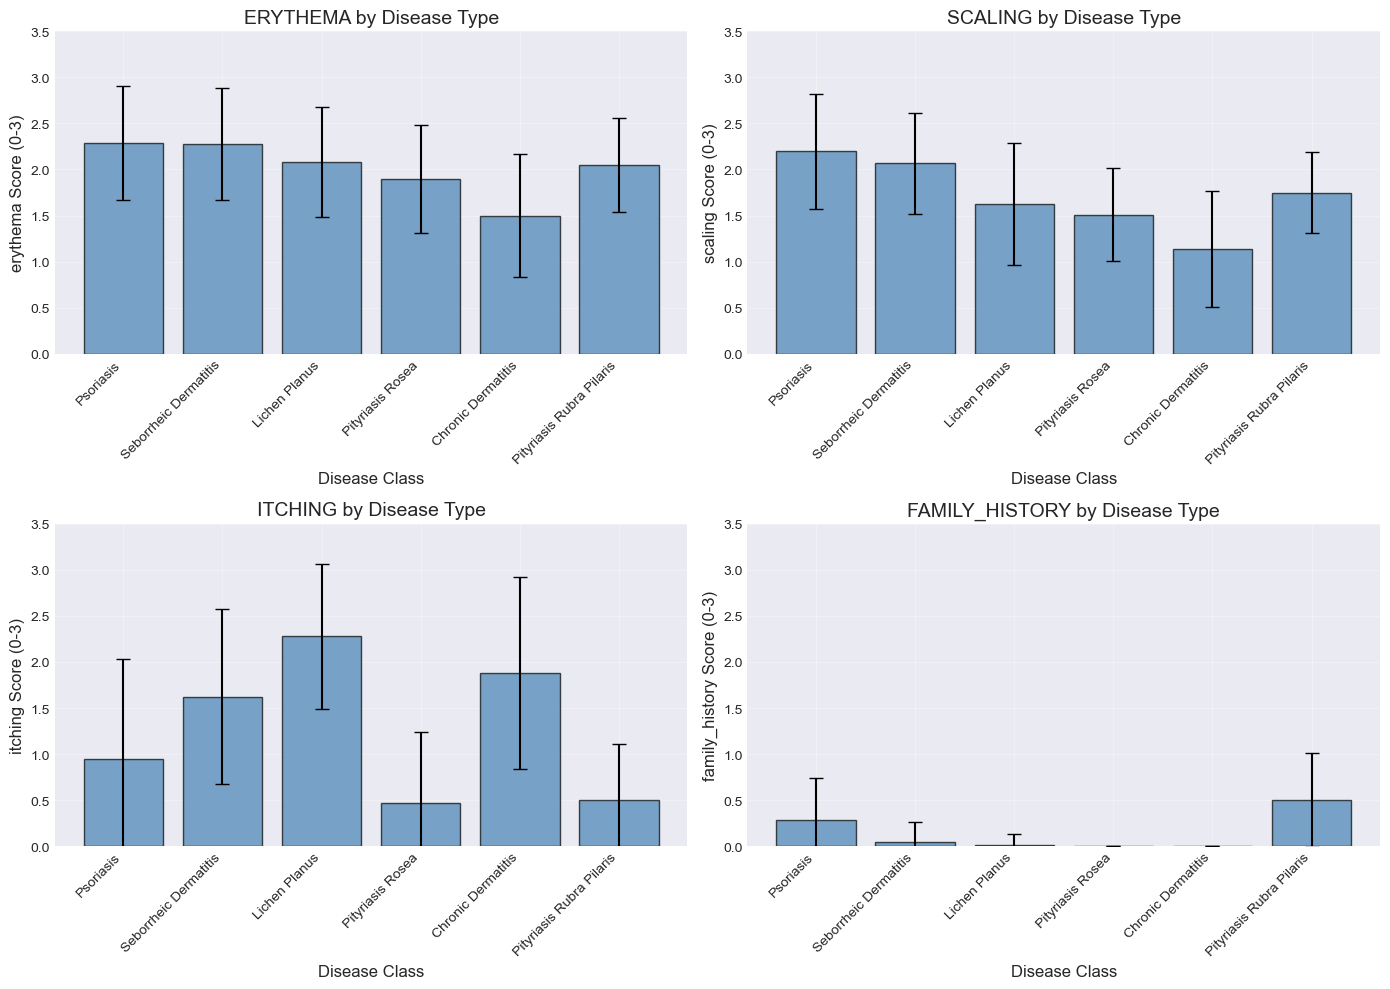

In [16]:
# Compare key features across different disease classes
key_features = ['erythema', 'scaling', 'itching', 'family_history']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(key_features):
    # Group by class
    class_means = df.groupby('class')[feature].mean()
    class_stds = df.groupby('class')[feature].std()
    
    axes[idx].bar(range(1, 7), class_means.values, yerr=class_stds.values, 
                  capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Disease Class', fontsize=12)
    axes[idx].set_ylabel(f'{feature} Score (0-3)', fontsize=12)
    axes[idx].set_title(f'{feature.upper()} by Disease Type', fontsize=14)
    axes[idx].set_xticks(range(1, 7))
    axes[idx].set_xticklabels([class_names[c] for c in range(1, 7)], rotation=45, ha='right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0, 3.5)

plt.tight_layout()
plt.show()

In [17]:
print("="*50)
print("OUTLIER DETECTION")
print("="*50)

# Check for outliers in age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
age_outliers = df[(df['age'] < Q1 - 1.5*IQR) | (df['age'] > Q3 + 1.5*IQR)]
print(f"Age outliers: {len(age_outliers)} patients")
if len(age_outliers) > 0:
    print(f"Outlier ages: {sorted(age_outliers['age'].tolist())}")

# Check for unusual patterns in features
print("\nFeatures with extreme values (score=3):")
for col in df.columns[:-1]:  # Exclude class column
    if col != 'age':
        pct_3 = (df[col] == 3).mean() * 100
        if pct_3 > 20:
            print(f"  {col}: {pct_3:.1f}% have score 3")

OUTLIER DETECTION
Age outliers: 0 patients

Features with extreme values (score=3):
  erythema: 24.6% have score 3
  itching: 20.8% have score 3
  acanthosis: 20.5% have score 3


In [18]:
print("="*50)
print("EDA SUMMARY & KEY INSIGHTS")
print("="*50)

print("\n1. DATASET CHARACTERISTICS:")
print(f"   - Total patients: {len(df)}")
print(f"   - Features: {df.shape[1]-1} (clinical + histopathological)")
print(f"   - Target: 6 disease classes")

print("\n2. CLASS IMBALANCE:")
print(f"   - Most common: {class_names[class_counts.idxmax()]} ({class_counts.max()} patients)")
print(f"   - Least common: {class_names[class_counts.idxmin()]} ({class_counts.min()} patients)")
print(f"   - Ratio: {class_counts.max()/class_counts.min():.1f}:1")

print("\n3. AGE INSIGHTS:")
print(f"   - Average patient age: {df['age'].mean():.1f} years")
print(f"   - Most affected age group: {df['age'].mode().values[0]:.0f} years")

print("\n4. FEATURE INSIGHTS:")
# Find most common symptoms (highest mean scores)
feature_means = df.drop(['age', 'class'], axis=1).mean().sort_values(ascending=False)
print("   Top 5 most severe symptoms (highest avg scores):")
for i in range(5):
    print(f"     {i+1}. {feature_means.index[i]}: {feature_means.values[i]:.2f}/3.0")

print("\n5. RECOMMENDATIONS FOR MODELING:")
if class_counts.max()/class_counts.min() > 2:
    print("   ⚠️  Use stratified train-test split due to class imbalance")
    print("   ⚠️  Consider SMOTE or class weights for classification")
print("   ✓ Features are properly scaled (0-3 range)")
print("   ✓ No missing values remain")
print("   ✓ Age feature is now clean")

EDA SUMMARY & KEY INSIGHTS

1. DATASET CHARACTERISTICS:
   - Total patients: 366
   - Features: 34 (clinical + histopathological)
   - Target: 6 disease classes

2. CLASS IMBALANCE:
   - Most common: Psoriasis (112 patients)
   - Least common: Pityriasis Rubra Pilaris (20 patients)
   - Ratio: 5.6:1

3. AGE INSIGHTS:
   - Average patient age: 36.3 years
   - Most affected age group: 35 years

4. FEATURE INSIGHTS:
   Top 5 most severe symptoms (highest avg scores):
     1. erythema: 2.07/3.0
     2. acanthosis: 1.96/3.0
     3. inflammatory_mononuclear_infiltrate: 1.87/3.0
     4. scaling: 1.80/3.0
     5. definite_borders: 1.55/3.0

5. RECOMMENDATIONS FOR MODELING:
   ⚠️  Use stratified train-test split due to class imbalance
   ⚠️  Consider SMOTE or class weights for classification
   ✓ Features are properly scaled (0-3 range)
   ✓ No missing values remain
   ✓ Age feature is now clean
